In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df = pd.read_excel('listings - CDMX_clean.xlsx') 
df.head()

,Unnamed: 0,id,host_id,beds,bedrooms,source,name,description,neighborhood_overview,host_name,...,number_of_reviews_ltm,number_of_reviews_l30d,review_scores_rating,review_scores_accuracy,review_scores_cleanliness,review_scores_checkin,review_scores_communication,review_scores_location,review_scores_value,reviews_per_month
0,1,44616,196253,1,5,previous scrape,Condesa Haus,A new concept of hosting in mexico through a b...,No neighborhood_overview,Fernando,...,0.0,0.0,4.58,4.56,4.70,4.87,4.78,4.98,4.48,0.41
1,2,67703,334451,2,2,city scrape,"2 bedroom apt. deco bldg, Condesa","Comfortably furnished, sunny, 2 bedroom apt., ...",No neighborhood_overview,Nicholas,...,4.0,0.0,4.90,4.81,4.75,4.94,4.92,4.98,4.91,0.31
2,3,70644,212109,1,1,city scrape,Beautiful light Studio Coyoacan- full equipped !,COYOACAN designer studio quiet & safe! well eq...,Coyoacan is a beautiful neighborhood famous fo...,Trisha,...,7.0,2.0,4.91,4.90,4.96,4.96,4.98,4.96,4.92,0.83
3,4,107078,540705,1,1,city scrape,NEW DESIGNER LOFT,Is the best ever place triple L <br />Location...,"Is located in the best area of Mexico City, Po...",Andrea,...,0.0,0.0,4.91,5.00,5.00,5.00,4.73,4.91,4.82,0.11
4,5,131610,647454,1,2,previous scrape,MARIA DEL ALMA,No description,No neighborhood_overview,Fernando,...,0.0,0.0,4.80,4.80,4.80,4.90,4.90,4.90,4.80,1.17


In [3]:
df = df[df['room_type'] == 'Entire home/apt']

C:\Users\issei\AppData\Local\Temp\ipykernel_51656\3158968366.py:8: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


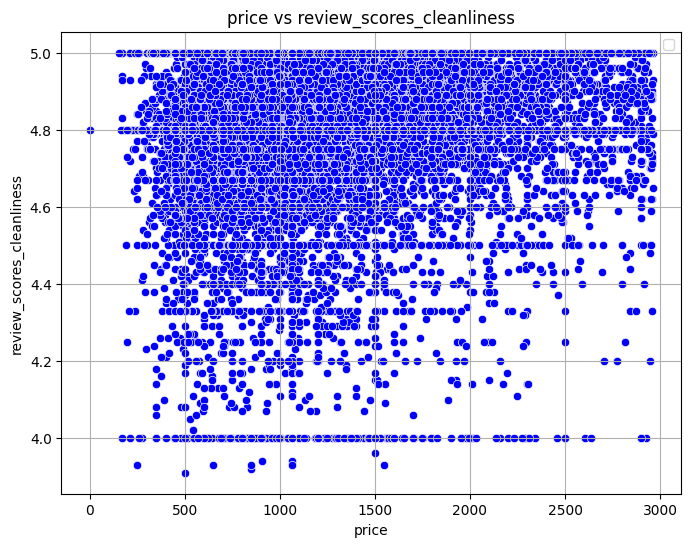

In [4]:
from turtle import color

plt.figure(figsize=(8, 6))
sns.scatterplot(y='review_scores_cleanliness', x='price',  color = 'blue', data=df)
plt.title('price vs review_scores_cleanliness')
plt.xlabel('price')
plt.ylabel('review_scores_cleanliness')
plt.legend()
plt.grid(True)
plt.show()

In [5]:
indep= df[['review_scores_cleanliness']]
dep = df[['price']]

In [6]:
from sklearn.linear_model import LinearRegression

model = LinearRegression()

In [7]:
model.fit(indep, dep)

LinearRegression()

In [8]:
type(model)

sklearn.linear_model._base.LinearRegression

In [9]:
model.__dict__

{'fit_intercept': True,
 'copy_X': True,
 'n_jobs': None,
 'positive': False,
 'feature_names_in_': array(['review_scores_cleanliness'], dtype=object),
 'n_features_in_': 1,
 'coef_': array([[256.77231247]]),
 'rank_': 1,
 'singular_': array([24.92682266]),
 'intercept_': array([1.43818441])}

In [10]:
m = model.coef_
b = model.intercept_
print('Pendiente:', m)
print('Intercepto:', b)

# Entonce, el modelo lineal sería:
print(f'y = {m[0]}x + {b}')

Pendiente: [[256.77231247]]
Intercepto: [1.43818441]
y = [256.77231247]x + [1.43818441]


In [11]:
r2 = model.score(indep, dep)
r2

0.007799881286113197

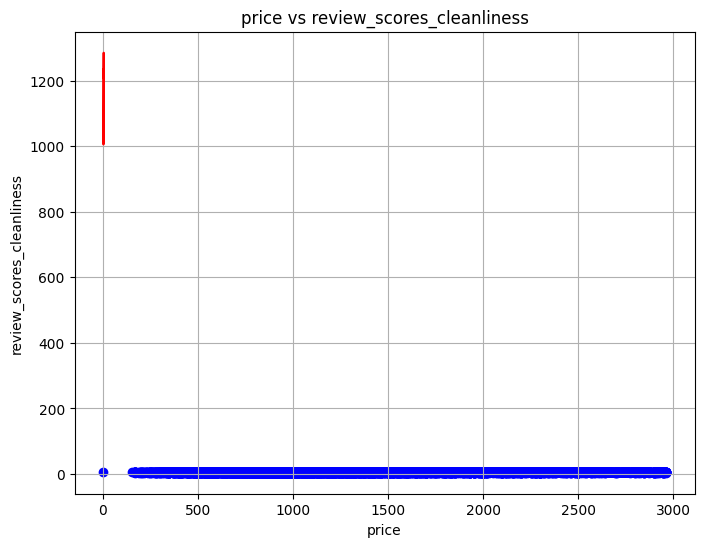

In [12]:
plt.figure(figsize=(8, 6))
plt.scatter(dep, indep, color='blue')
plt.plot(indep, model.predict(indep), color='red')
plt.title('price vs review_scores_cleanliness')
plt.xlabel('price')
plt.ylabel('review_scores_cleanliness')
plt.grid(True)
plt.show()

In [13]:
yPred = model.predict(df[['review_scores_cleanliness']])
yPred

array([[1208.26805302],
       [1221.10666864],
       [1275.02885426],
       ...,
       [1233.94528427],
       [1233.94528427],
       [1233.94528427]])

In [14]:
df['Predicciones'] = yPred
df.head()

,Unnamed: 0,id,host_id,beds,bedrooms,source,name,description,neighborhood_overview,host_name,...,number_of_reviews_l30d,review_scores_rating,review_scores_accuracy,review_scores_cleanliness,review_scores_checkin,review_scores_communication,review_scores_location,review_scores_value,reviews_per_month,Predicciones
0,1,44616,196253,1,5,previous scrape,Condesa Haus,A new concept of hosting in mexico through a b...,No neighborhood_overview,Fernando,...,0.0,4.58,4.56,4.70,4.87,4.78,4.98,4.48,0.41,1208.268053
1,2,67703,334451,2,2,city scrape,"2 bedroom apt. deco bldg, Condesa","Comfortably furnished, sunny, 2 bedroom apt., ...",No neighborhood_overview,Nicholas,...,0.0,4.90,4.81,4.75,4.94,4.92,4.98,4.91,0.31,1221.106669
2,3,70644,212109,1,1,city scrape,Beautiful light Studio Coyoacan- full equipped !,COYOACAN designer studio quiet & safe! well eq...,Coyoacan is a beautiful neighborhood famous fo...,Trisha,...,2.0,4.91,4.90,4.96,4.96,4.98,4.96,4.92,0.83,1275.028854
3,4,107078,540705,1,1,city scrape,NEW DESIGNER LOFT,Is the best ever place triple L <br />Location...,"Is located in the best area of Mexico City, Po...",Andrea,...,0.0,4.91,5.00,5.00,5.00,4.73,4.91,4.82,0.11,1285.299747
5,6,165772,790208,10,5,city scrape,BEST 5 Bedroom HOUSE IN S. Miguel Chapultepec,Welcome to Your Home in Mexico City<br />We ha...,San Miguel Chapultepec is the best kept secret...,Francisco Carlos,...,0.0,4.88,4.91,4.84,4.92,4.90,4.75,4.90,2.23,1244.216177


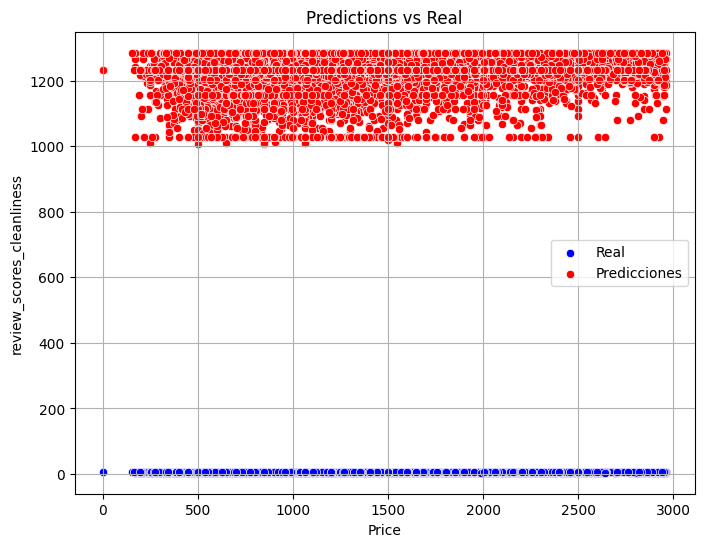

In [15]:
plt.figure(figsize=(8, 6 ))
sns.scatterplot(x='price', y='review_scores_cleanliness', color='blue', data=df, label='Real')
sns.scatterplot(x='price', y='Predicciones', color='red', data=df, label='Predicciones')
#sns.lineplot(x='alcohol', y='Predicciones', color='red', data=df, label='Predicciones')
plt.title('Predictions vs Real')
plt.xlabel('Price')
plt.ylabel('review_scores_cleanliness')
plt.legend()
plt.grid(True)
plt.show()

In [16]:
coefDe = model.score(indep, dep)
coefDe

0.007799881286113197

In [17]:
coefCo = np.sqrt(coefDe)
coefCo

0.0883169365756829